In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def importar_dados(caminho):
    dados = pd.read_csv(caminho)
    dados['data_iniSE'] = pd.to_datetime(dados['data_iniSE'])
    dados = dados.set_index('data_iniSE')
    dados = dados.asfreq('W-SUN')
    dados = dados.rename(columns={'umidmed': 'umidade', 'tempmed': 'temperatura'})
    dados = dados.dropna()
    return dados

In [4]:
dados_d = importar_dados('./dados/dengue_tratado.csv')
dados_ch = importar_dados('./dados/chikungunya_tratado.csv')
dados_zk = importar_dados('./dados/zika_tratado.csv')

def dividir_treino_teste(dados, data_limite):
    treino = dados[dados.index <= data_limite]
    teste = dados[dados.index > data_limite]
    treino = treino.drop(treino[["umidade", "temperatura"]], axis=1)
    teste = teste.drop(teste[["umidade", "temperatura"]], axis=1)
    return treino, teste

treino_d, teste_d = dividir_treino_teste(dados_d,'2022-01-02')
treino_ch, teste_ch = dividir_treino_teste(dados_ch,'2023-01-01')
treino_zk, teste_zk = dividir_treino_teste(dados_zk,'2023-01-01')

In [5]:
teste_d.index = pd.to_datetime(teste_d.index)

In [6]:
medmov_dengue = pd.read_csv("./resultados/medmov/MedMov_Dengue.csv", index_col="data")
medmov_chik = pd.read_csv("./resultados/medmov/MedMov_Chikungunya.csv", index_col="data")
medmov_zk = pd.read_csv("./resultados/medmov/MedMov_Zika.csv", index_col="data")

In [7]:
xgb_dengue = pd.read_csv("./resultados/xgboost/xgboost_Dengue.csv", index_col="data")
xgb_chik = pd.read_csv("./resultados/xgboost/xgboost_Chikungunya.csv", index_col="data")
xgb_zk = pd.read_csv("./resultados/xgboost/xgboost_Zika.csv", index_col="data")

In [8]:
sarimax_dengue = pd.read_csv("./resultados/sarimax/sarimax_Dengue.csv", index_col="data")
sarimax_chik = pd.read_csv("./resultados/sarimax/sarimax_Chikungunya.csv", index_col="data")
sarimax_zk = pd.read_csv("./resultados/sarimax/sarimax_Zika.csv", index_col="data")

In [9]:
mlpforecast_dengue = pd.read_csv("./resultados/mlpforecast/mlpforecast_Dengue.csv", index_col="data")
mlpforecast_chik = pd.read_csv("./resultados/mlpforecast/mlpforecast_Chikungunya.csv", index_col="data")
mlpforecast_zk = pd.read_csv("./resultados/mlpforecast/mlpforecast_Zika.csv", index_col="data")

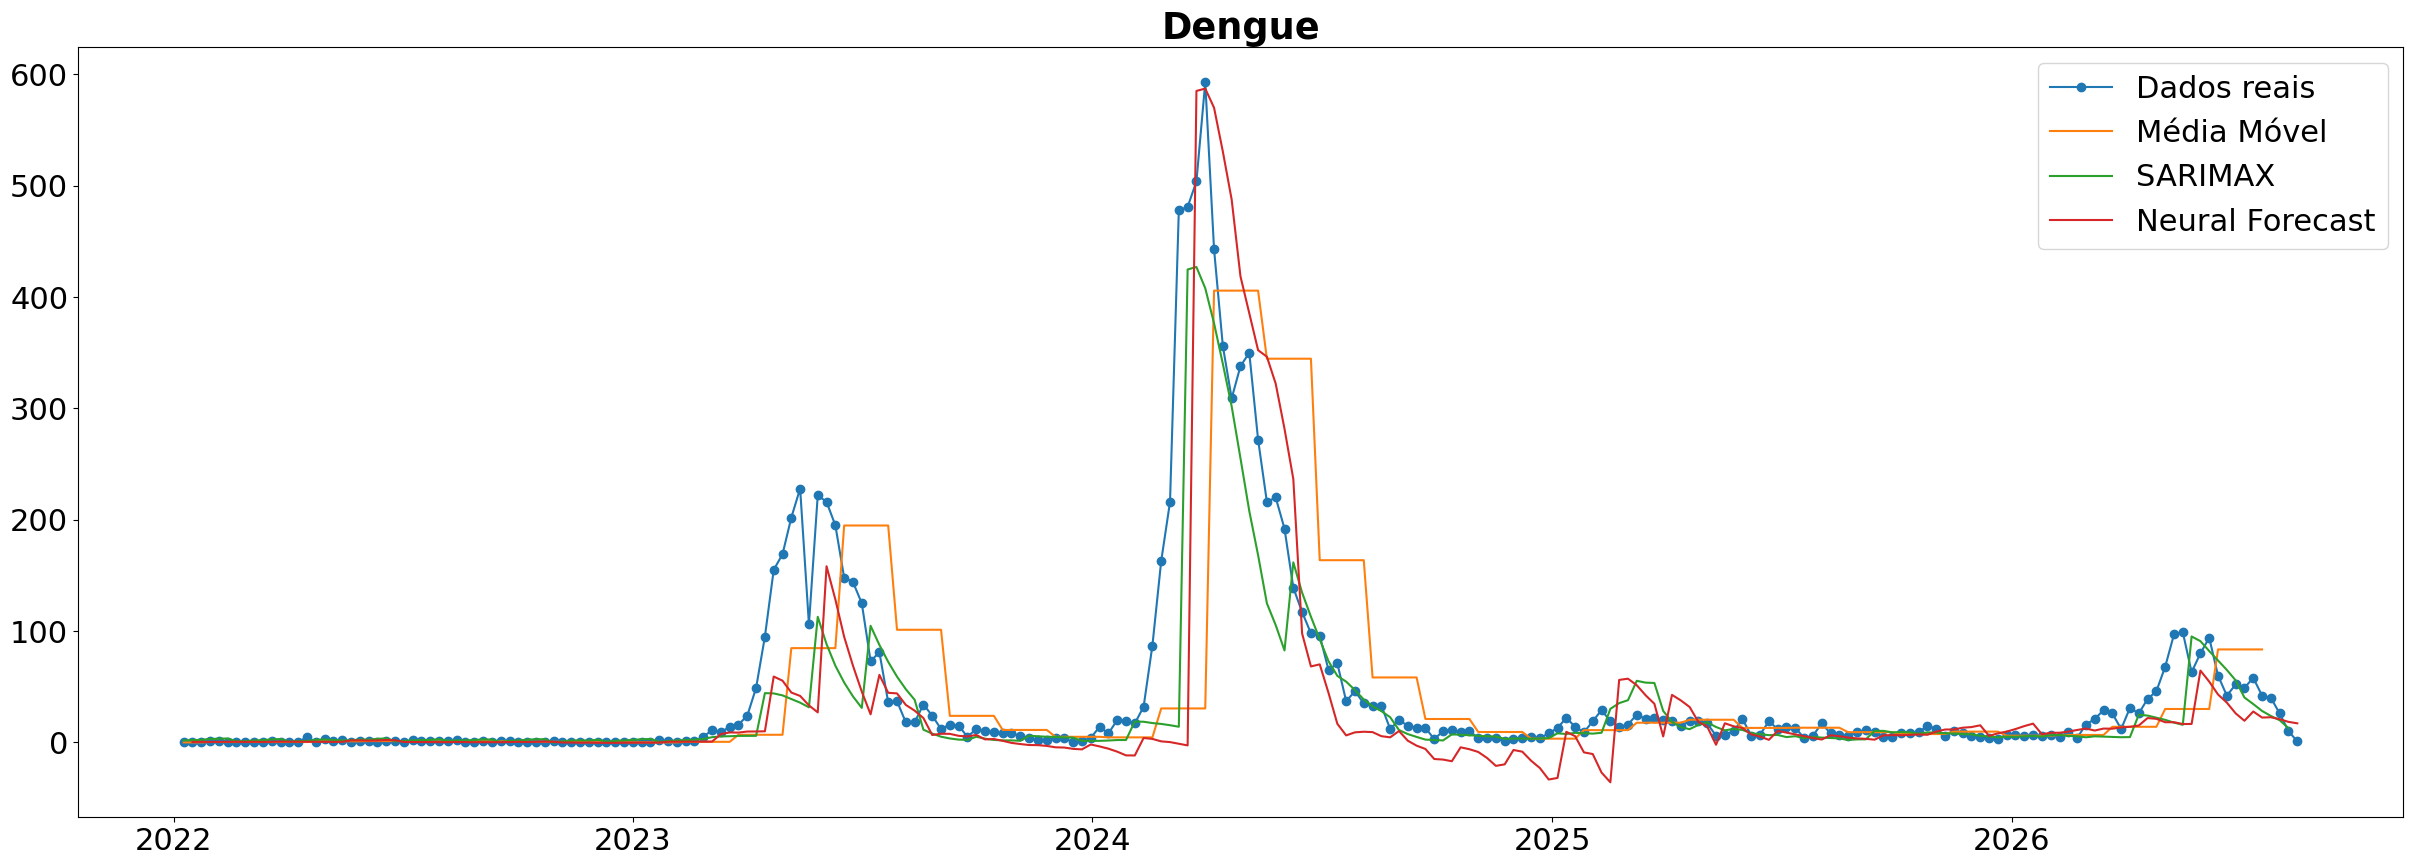

In [15]:
medmov_dengue.index = pd.to_datetime(medmov_dengue.index)
sarimax_dengue.index = pd.to_datetime(sarimax_dengue.index)
xgb_dengue.index = pd.to_datetime(xgb_dengue.index)
mlpforecast_dengue.index = pd.to_datetime(mlpforecast_dengue.index)

plt.figure(figsize=(30,10))
plt.rcParams.update({'font.size': 22})
plt.title("Dengue", fontweight='bold')
plt.plot(teste_d, label="Dados reais", marker="o")
plt.plot(medmov_dengue["y_pred"].loc["2022-01-09":], label="Média Móvel")
plt.plot(sarimax_dengue["y_pred"], label="SARIMAX")
plt.plot(mlpforecast_dengue["y_pred"], label="Neural Forecast")
plt.legend()
plt.savefig('./graficos/Modelos_Dengue.png', bbox_inches='tight', dpi=300)
plt.show()


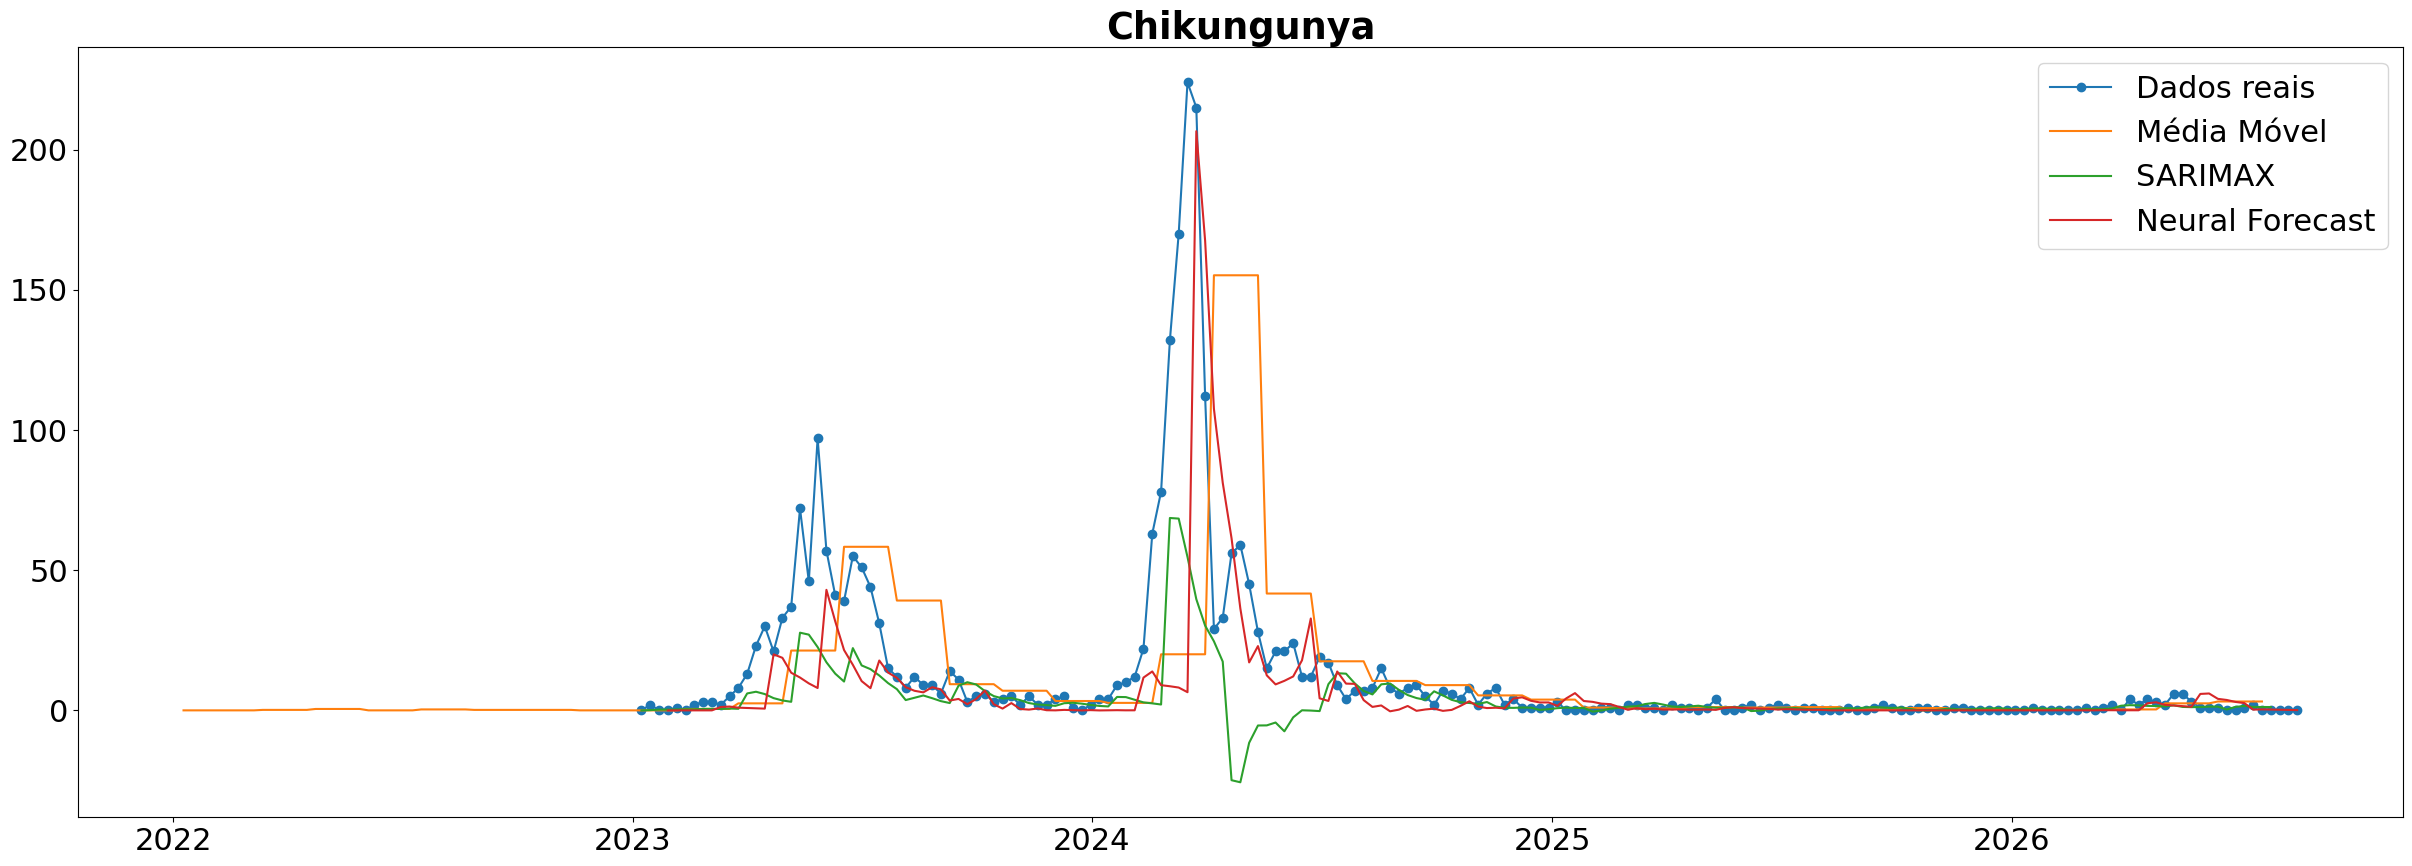

In [16]:
medmov_chik.index = pd.to_datetime(medmov_chik.index)
sarimax_chik.index = pd.to_datetime(sarimax_chik.index)
xgb_chik.index = pd.to_datetime(xgb_chik.index)
mlpforecast_chik.index = pd.to_datetime(mlpforecast_chik.index)

plt.figure(figsize=(30,10))
plt.rcParams.update({'font.size': 22})
plt.title("Chikungunya", fontweight='bold')
plt.plot(teste_ch, label="Dados reais", marker="o")
plt.plot(medmov_chik["y_pred"].loc["2022-01-09":], label="Média Móvel")
plt.plot(sarimax_chik["y_pred"], label="SARIMAX")
plt.plot(mlpforecast_chik["y_pred"], label="Neural Forecast")
plt.legend()
plt.savefig('./graficos/Modelos_Chikungunya.png', bbox_inches='tight', dpi=300)
plt.show()

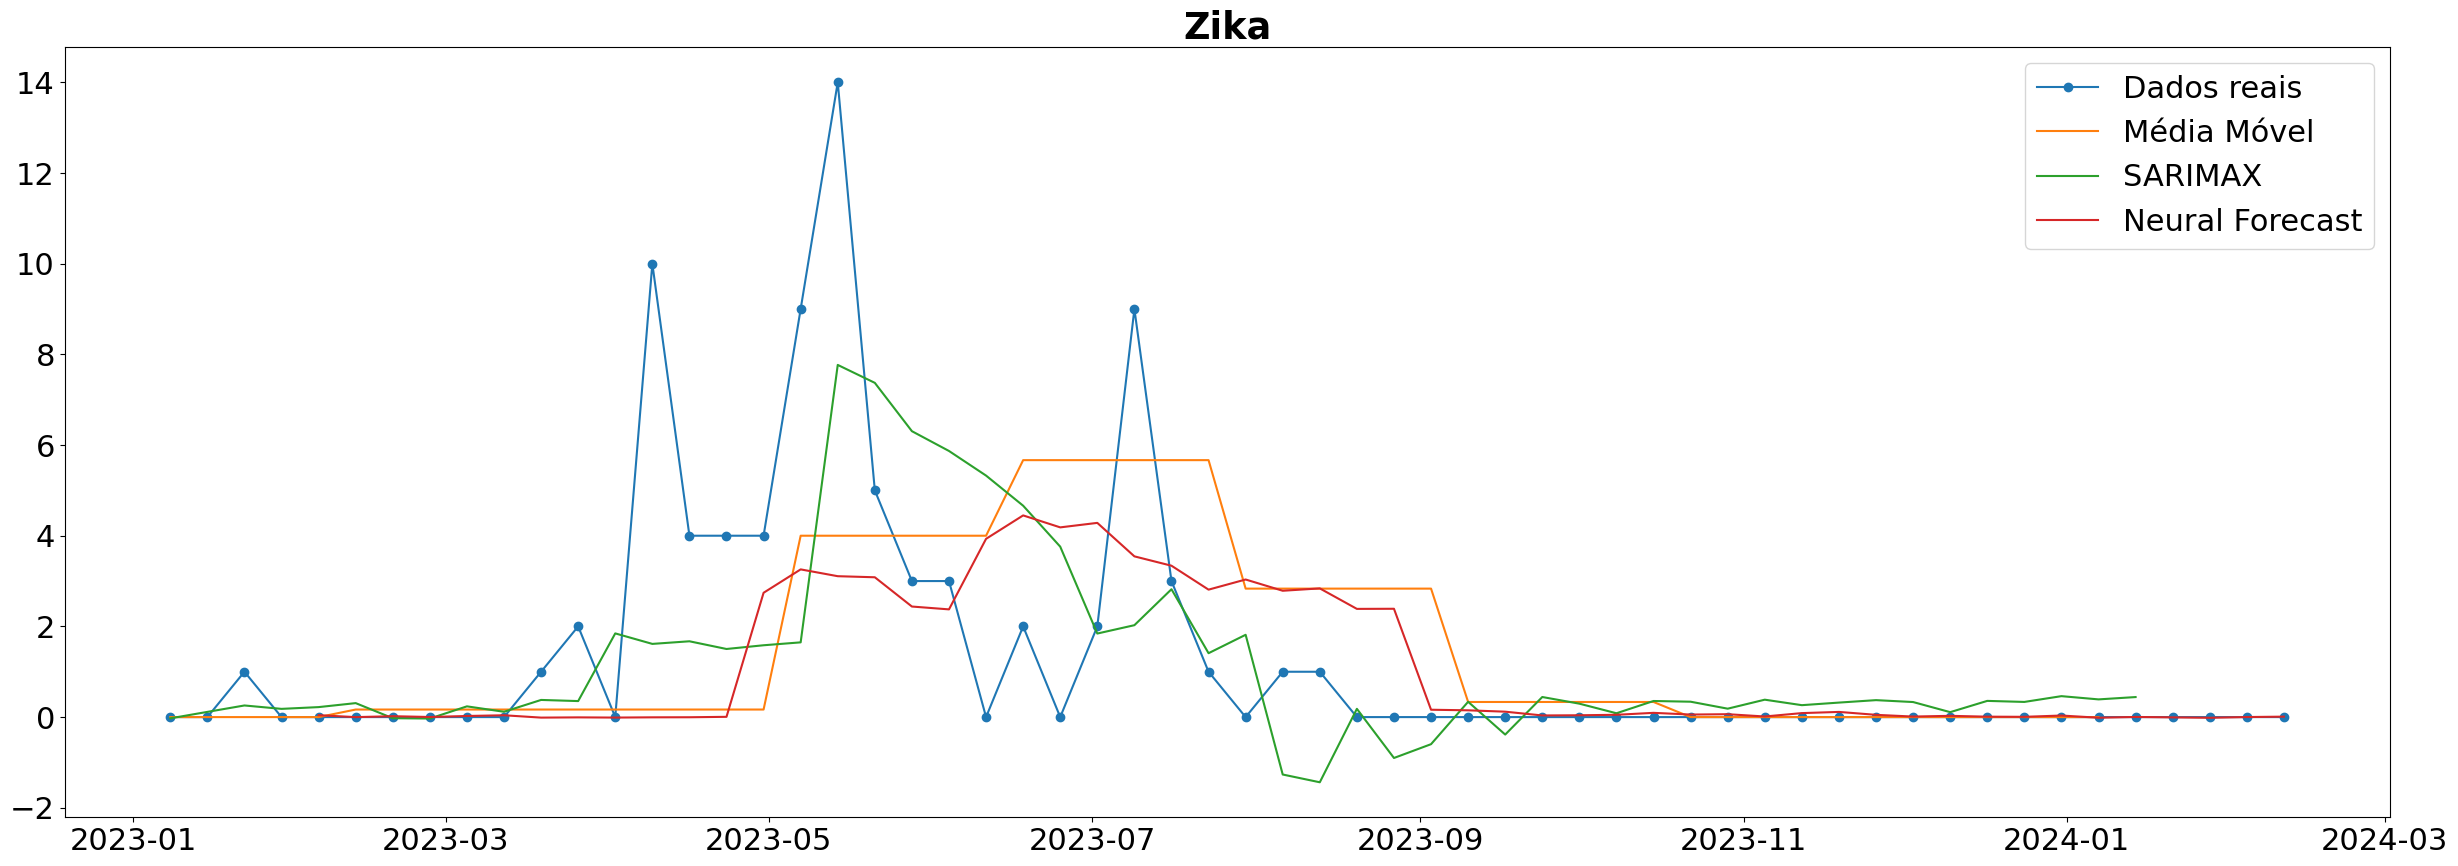

In [17]:
medmov_zk.index = pd.to_datetime(medmov_zk.index)
sarimax_zk.index = pd.to_datetime(sarimax_zk.index)
xgb_zk.index = pd.to_datetime(xgb_zk.index)
mlpforecast_zk.index = pd.to_datetime(mlpforecast_zk.index)

plt.figure(figsize=(30,10))
plt.rcParams.update({'font.size': 22})
plt.title("Zika", fontweight='bold')
plt.plot(teste_zk, label="Dados reais", marker="o")
plt.plot(medmov_zk["y_pred"].loc["2023-01-08":], label="Média Móvel")
plt.plot(sarimax_zk["y_pred"], label="SARIMAX")
plt.plot(mlpforecast_zk["y_pred"], label="Neural Forecast")
plt.legend()
plt.savefig('./graficos/Modelos_Zika.png', bbox_inches='tight', dpi=300)
plt.show()